In [1]:
# =========================================================
# STEP 1: Load SOURCE and TARGET data, then split TARGET
# New clean pipeline
# =========================================================

import os
import glob
import random
import numpy as np
import scipy.io as sio
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# ONLY CHANGE THESE TWO PATHS IF NEEDED
# -----------------------------
TARGET_BASE = r"G:\Data Sets\Cutting tool organized\Vibration_1440_1"
SOURCE_BASE = r"G:\Data Sets\Cutting tool organized\Vibration_1320_1"

# -----------------------------
# Settings
# -----------------------------
SOURCE_RPM = 1320
TARGET_RPM = 1440
TEST_SIZE = 0.20

CLASS_NAMES = ["BF", "GF", "N", "TF"]
CLASS_TO_ID = {"BF": 0, "GF": 1, "N": 2, "TF": 3}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

FOLDERS_TGT = {
    "BF": "Vib_BF1440_1",
    "GF": "Vib_GF1440_1",
    "N" : "Vib_N1440_1",
    "TF": "Vib_TF1440_1",
}

FOLDERS_SRC = {
    "BF": "Vib_BF1320_1",
    "GF": "Vib_GF1320_1",
    "N" : "Vib_N1320_1",
    "TF": "Vib_TF1320_1",
}

# -----------------------------
# Loader
# -----------------------------
def load_domain(base_path, folder_map, rpm_value, class_names):
    X, Y, D, FS, PATHS = [], [], [], [], []

    print(f"\nLoading domain: {rpm_value} rpm")
    for cls in class_names:
        folder = os.path.join(base_path, folder_map[cls])
        files = sorted(glob.glob(os.path.join(folder, "*.mat")))
        print(f"{rpm_value} rpm | {cls} | files = {len(files)}")

        if len(files) == 0:
            raise FileNotFoundError(f"No .mat files found in folder: {folder}")

        for fp in files:
            mat = sio.loadmat(fp)

            if "signals" not in mat:
                raise KeyError(f"'signals' not found in file: {fp}")
            if "fs" not in mat:
                raise KeyError(f"'fs' not found in file: {fp}")

            sig = np.array(mat["signals"], dtype=np.float32)
            fs_val = float(np.squeeze(mat["fs"]))

            if sig.ndim != 2:
                raise ValueError(f"'signals' must be 2D in file: {fp}, got shape {sig.shape}")
            if sig.shape[0] != 2:
                raise ValueError(f"'signals' first dimension must be 2 in file: {fp}, got shape {sig.shape}")
            if sig.shape[1] <= 0:
                raise ValueError(f"Invalid signal length in file: {fp}, got shape {sig.shape}")

            X.append(sig)
            Y.append(cls)
            D.append(rpm_value)
            FS.append(fs_val)
            PATHS.append(fp)

    return X, Y, D, FS, PATHS

# -----------------------------
# Load source and target
# -----------------------------
Xs, Ys, Ds, FSs, Ps = load_domain(SOURCE_BASE, FOLDERS_SRC, SOURCE_RPM, CLASS_NAMES)
Xt, Yt, Dt, FSt, Pt = load_domain(TARGET_BASE, FOLDERS_TGT, TARGET_RPM, CLASS_NAMES)

# -----------------------------
# Summary before split
# -----------------------------
print("\n================ LOADED SUMMARY ================")
print("Source samples:", len(Xs))
print("Target samples:", len(Xt))
print("Counts per class source:", dict(Counter(Ys)))
print("Counts per class target:", dict(Counter(Yt)))

# -----------------------------
# Stratified split on target
# target train -> unlabeled adaptation set
# target test  -> labeled evaluation set
# -----------------------------
y_target_ids = np.array([CLASS_TO_ID[y] for y in Yt], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
idx_train_t, idx_test_t = next(sss.split(np.zeros(len(y_target_ids)), y_target_ids))

Xt_train = [Xt[i] for i in idx_train_t]
Yt_train = [Yt[i] for i in idx_train_t]
Dt_train = [Dt[i] for i in idx_train_t]
FSt_train = [FSt[i] for i in idx_train_t]
Pt_train = [Pt[i] for i in idx_train_t]

Xt_test = [Xt[i] for i in idx_test_t]
Yt_test = [Yt[i] for i in idx_test_t]
Dt_test = [Dt[i] for i in idx_test_t]
FSt_test = [FSt[i] for i in idx_test_t]
Pt_test = [Pt[i] for i in idx_test_t]

# -----------------------------
# Print split summary
# -----------------------------
print("\n================ TARGET SPLIT ================")
print("Target train (unlabeled) samples:", len(Xt_train))
print("Target test  (labeled) samples  :", len(Xt_test))
print("Counts per class target train:", dict(Counter(Yt_train)))
print("Counts per class target test :", dict(Counter(Yt_test)))

# -----------------------------
# Sanity checks
# -----------------------------
print("\n================ SANITY CHECKS ================")
print("Source example signal shape:", Xs[0].shape)
print("Target example signal shape:", Xt[0].shape)

print("Unique fs source:", sorted(list(set([round(v, 6) for v in FSs]))))
print("Unique fs target:", sorted(list(set([round(v, 6) for v in FSt]))))

assert len(Xs) > 0, "Source data is empty"
assert len(Xt) > 0, "Target data is empty"
assert len(Xt_train) > 0, "Target train split is empty"
assert len(Xt_test) > 0, "Target test split is empty"

assert Xs[0].shape[0] == 2, "Source signals must have 2 channels"
assert Xt[0].shape[0] == 2, "Target signals must have 2 channels"

print("\nStep 1 completed successfully.")


Loading domain: 1320 rpm
1320 rpm | BF | files = 112
1320 rpm | GF | files = 111
1320 rpm | N | files = 116
1320 rpm | TF | files = 112

Loading domain: 1440 rpm
1440 rpm | BF | files = 112
1440 rpm | GF | files = 110
1440 rpm | N | files = 112
1440 rpm | TF | files = 112

================ LOADED SUMMARY ================
Source samples: 451
Target samples: 446
Counts per class source: {'BF': 112, 'GF': 111, 'N': 116, 'TF': 112}
Counts per class target: {'BF': 112, 'GF': 110, 'N': 112, 'TF': 112}

================ TARGET SPLIT ================
Target train (unlabeled) samples: 356
Target test  (labeled) samples  : 90
Counts per class target train: {'GF': 88, 'N': 89, 'BF': 90, 'TF': 89}
Counts per class target test : {'GF': 22, 'N': 23, 'TF': 23, 'BF': 22}

================ SANITY CHECKS ================
Source example signal shape: (2, 25600)
Target example signal shape: (2, 25600)
Unique fs source: [25600.0]
Unique fs target: [25600.0]

Step 1 completed successfully.


In [2]:
# =========================================================
# STEP 2: Nonlinear feature extraction
# - Global nonlinear features: (N, 16)
# - Patch nonlinear features : (N, 100, 4)
# - Normalize global features using SOURCE only
# =========================================================

import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree

PATCH_SIZE = 256

# -----------------------------
# Helper functions
# -----------------------------
def _safe_std(x):
    s = float(np.std(x))
    return s if s > 1e-12 else 1e-12

def _embed(x, m, tau=1):
    x = np.asarray(x, dtype=np.float64)
    n = len(x) - (m - 1) * tau
    if n <= 1:
        return None
    return np.array([x[i:i + m * tau:tau] for i in range(n)], dtype=np.float64)

# -----------------------------
# Entropy and complexity features
# -----------------------------
def sampen_balltree(x, m=2, r=0.2, downsample=10):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    if len(x) < (m + 1) * 2 + 5:
        return 0.0

    sd = _safe_std(x)
    rad = r * sd

    Xm = _embed(x, m, 1)
    Xm1 = _embed(x, m + 1, 1)
    if Xm is None or Xm1 is None:
        return 0.0

    tree_m = BallTree(Xm, metric="chebyshev")
    tree_m1 = BallTree(Xm1, metric="chebyshev")

    Cm = tree_m.query_radius(Xm, r=rad, count_only=True).astype(np.float64) - 1.0
    Cm1 = tree_m1.query_radius(Xm1, r=rad, count_only=True).astype(np.float64) - 1.0

    Cm = np.maximum(Cm, 0.0)
    Cm1 = np.maximum(Cm1, 0.0)

    A = np.sum(Cm1) + 1e-12
    B = np.sum(Cm) + 1e-12
    return float(-np.log(A / B))

def apen_balltree(x, m=2, r=0.2, downsample=10):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    if len(x) < (m + 1) * 2 + 5:
        return 0.0

    sd = _safe_std(x)
    rad = r * sd

    Xm = _embed(x, m, 1)
    Xm1 = _embed(x, m + 1, 1)
    if Xm is None or Xm1 is None:
        return 0.0

    tree_m = BallTree(Xm, metric="chebyshev")
    tree_m1 = BallTree(Xm1, metric="chebyshev")

    Cm = tree_m.query_radius(Xm, r=rad, count_only=True).astype(np.float64)
    Cm1 = tree_m1.query_radius(Xm1, r=rad, count_only=True).astype(np.float64)

    Cm = Cm / (len(Xm) + 1e-12)
    Cm1 = Cm1 / (len(Xm1) + 1e-12)

    phi_m = np.mean(np.log(Cm + 1e-12))
    phi_m1 = np.mean(np.log(Cm1 + 1e-12))
    return float(phi_m - phi_m1)

def perm_entropy(x, order=5, delay=1, normalize=True, downsample=5):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    n = len(x)
    if n < order * delay + 2:
        return 0.0

    patterns = {}
    for i in range(n - delay * (order - 1)):
        window = x[i:i + delay * order:delay]
        key = tuple(np.argsort(window))
        patterns[key] = patterns.get(key, 0) + 1

    counts = np.array(list(patterns.values()), dtype=np.float64)
    p = counts / (np.sum(counts) + 1e-12)
    pe = -np.sum(p * np.log(p + 1e-12))

    if normalize:
        pe /= np.log(math.factorial(order) + 1e-12)
    return float(pe)

def weighted_perm_entropy(x, order=5, delay=1, normalize=True, downsample=5):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    n = len(x)
    if n < order * delay + 2:
        return 0.0

    weights = {}
    for i in range(n - delay * (order - 1)):
        window = x[i:i + delay * order:delay]
        key = tuple(np.argsort(window))
        w = float(np.var(window) + 1e-12)
        weights[key] = weights.get(key, 0.0) + w

    vals = np.array(list(weights.values()), dtype=np.float64)
    p = vals / (np.sum(vals) + 1e-12)
    wpe = -np.sum(p * np.log(p + 1e-12))

    if normalize:
        wpe /= np.log(math.factorial(order) + 1e-12)
    return float(wpe)

def higuchi_fd(x, kmax=8, downsample=2):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    n = len(x)
    if n < 20:
        return 1.0

    Lk = []
    ks = range(1, kmax + 1)

    for k in ks:
        Lm = []
        for m in range(k):
            idx = np.arange(m, n, k)
            if len(idx) < 2:
                continue
            diff = np.abs(np.diff(x[idx]))
            L = np.sum(diff) * (n - 1) / (len(idx) * k + 1e-12)
            Lm.append(L)
        if len(Lm) > 0:
            Lk.append(np.mean(Lm))

    if len(Lk) < 2:
        return 1.0

    lnL = np.log(np.array(Lk) + 1e-12)
    lnk = np.log(1.0 / (np.arange(1, len(Lk) + 1, dtype=np.float64) + 1e-12))
    slope = np.polyfit(lnk, lnL, 1)[0]
    return float(slope)

def katz_fd(x, downsample=2):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    n = len(x)
    if n < 5:
        return 1.0

    dists = np.abs(np.diff(x))
    L = np.sum(dists) + 1e-12
    d = np.max(np.abs(x - x[0])) + 1e-12
    return float(np.log10(n) / (np.log10(d / L) + np.log10(n) + 1e-12))

def lz_complexity(x, downsample=2):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    if len(x) < 20:
        return 0.0

    thr = np.median(x)
    s = (x > thr).astype(np.int8)

    i, k, l = 0, 1, 1
    c = 1
    n = len(s)

    while True:
        if i + k >= n or l + k >= n:
            break
        if s[i + k] == s[l + k]:
            k += 1
            if l + k >= n:
                c += 1
                break
        else:
            if k > 1:
                i += 1
                if i == l:
                    c += 1
                    l += k
                    if l >= n:
                        break
                    i, k = 0, 1
            else:
                i += 1
                if i == l:
                    c += 1
                    l += 1
                    if l >= n:
                        break
                    i, k = 0, 1

    return float(c / (n / np.log2(n + 1e-12) + 1e-12))

def hurst_rs(x, downsample=4):
    x = np.asarray(x, dtype=np.float64)[::downsample]
    n = len(x)
    if n < 50:
        return 0.5

    x = x - np.mean(x)
    y = np.cumsum(x)
    R = np.max(y) - np.min(y) + 1e-12
    S = _safe_std(x)
    return float(np.log(R / S) / (np.log(n + 1e-12) + 1e-12))

# -----------------------------
# Global nonlinear features
# 8 features per channel
# then channel-wise mean and std
# final: 16 dims
# -----------------------------
def nonlinear_vector_1ch(x):
    feats = []
    feats.append(sampen_balltree(x, m=2, r=0.2, downsample=10))
    feats.append(apen_balltree(x, m=2, r=0.2, downsample=10))
    feats.append(perm_entropy(x, order=5, delay=1, downsample=5))
    feats.append(weighted_perm_entropy(x, order=5, delay=1, downsample=5))
    feats.append(higuchi_fd(x, kmax=8, downsample=2))
    feats.append(katz_fd(x, downsample=2))
    feats.append(lz_complexity(x, downsample=2))
    feats.append(hurst_rs(x, downsample=4))
    return np.array(feats, dtype=np.float32)

def nonlinear_global_2ch(sig2ch):
    per_ch = []
    for ch in range(sig2ch.shape[0]):
        per_ch.append(nonlinear_vector_1ch(sig2ch[ch]))
    per_ch = np.stack(per_ch, axis=0)  # (2, 8)

    mean_feats = per_ch.mean(axis=0)   # (8,)
    std_feats  = per_ch.std(axis=0)    # (8,)
    g = np.concatenate([mean_feats, std_feats], axis=0)  # (16,)
    return g.astype(np.float32)

# -----------------------------
# Patch-level nonlinear features
# based on mean signal
# final per sample: (100, 4)
# -----------------------------
def sampen_small(x, m=2, r=0.2):
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    if n < (m + 1) * 2 + 2:
        return 0.0

    sd = _safe_std(x)
    rad = r * sd

    Xm = _embed(x, m, 1)
    Xm1 = _embed(x, m + 1, 1)
    if Xm is None or Xm1 is None:
        return 0.0

    dist_m = np.max(np.abs(Xm[:, None, :] - Xm[None, :, :]), axis=2)
    dist_m1 = np.max(np.abs(Xm1[:, None, :] - Xm1[None, :, :]), axis=2)

    np.fill_diagonal(dist_m, np.inf)
    np.fill_diagonal(dist_m1, np.inf)

    B = np.sum(dist_m <= rad) + 1e-12
    A = np.sum(dist_m1 <= rad) + 1e-12
    return float(-np.log(A / B))

def nonlinear_patch_mean(sig2ch, patch_size=PATCH_SIZE):
    x = sig2ch.mean(axis=0)
    L = x.shape[0]
    T = L // patch_size
    x = x[:T * patch_size].reshape(T, patch_size)

    patch_feats = []
    for t in range(T):
        xt = x[t]
        pe = perm_entropy(xt, order=4, delay=1, downsample=1)
        se = sampen_small(xt, m=2, r=0.2)
        hfd = higuchi_fd(xt, kmax=6, downsample=1)
        lzc = lz_complexity(xt, downsample=1)
        patch_feats.append([pe, se, hfd, lzc])

    return np.array(patch_feats, dtype=np.float32)  # (T, 4)

def extract_all_nonlinear(X_list):
    Pg = []
    Pp = []

    for i in range(len(X_list)):
        Pg.append(nonlinear_global_2ch(X_list[i]))
        Pp.append(nonlinear_patch_mean(X_list[i]))

        if (i + 1) % 100 == 0 or (i + 1) == len(X_list):
            print(f"Processed {i+1}/{len(X_list)} samples")

    Pg = np.vstack(Pg)
    Pp = np.stack(Pp, axis=0)
    return Pg, Pp

# -----------------------------
# Extract for source, target train, target test
# -----------------------------
print("\nExtracting source nonlinear features ...")
Pg_s, Pp_s = extract_all_nonlinear(Xs)

print("\nExtracting target train nonlinear features ...")
Pg_tu, Pp_tu = extract_all_nonlinear(Xt_train)

print("\nExtracting target test nonlinear features ...")
Pg_tt, Pp_tt = extract_all_nonlinear(Xt_test)

print("\n================ FEATURE SHAPES ================")
print("Global nonlinear shapes  :",
      "source =", Pg_s.shape,
      "| target_train =", Pg_tu.shape,
      "| target_test =", Pg_tt.shape)

print("Patch nonlinear shapes   :",
      "source =", Pp_s.shape,
      "| target_train =", Pp_tu.shape,
      "| target_test =", Pp_tt.shape)

# -----------------------------
# Normalize global nonlinear features
# using SOURCE only
# -----------------------------
scaler_global = StandardScaler()
Pg_s_norm = scaler_global.fit_transform(Pg_s)
Pg_tu_norm = scaler_global.transform(Pg_tu)
Pg_tt_norm = scaler_global.transform(Pg_tt)

print("\n================ NORMALIZATION CHECK ================")
print("Source normalized mean first 5:", np.round(Pg_s_norm.mean(axis=0)[:5], 4))
print("Source normalized std  first 5:", np.round(Pg_s_norm.std(axis=0)[:5], 4))

print("\n================ VALIDATION CHECKS ================")
print("Any NaN in source global :", np.isnan(Pg_s_norm).any())
print("Any NaN in target global :", np.isnan(Pg_tu_norm).any(), np.isnan(Pg_tt_norm).any())
print("Any NaN in source patch  :", np.isnan(Pp_s).any())
print("Any NaN in target patch  :", np.isnan(Pp_tu).any(), np.isnan(Pp_tt).any())

print("Patch length check source:", Pp_s.shape[1], "(expected 100)")
print("Patch length check target:", Pp_tu.shape[1], "(expected 100)")

print("\nExample source global feature first 6:", np.round(Pg_s[0][:6], 4))
print("Example source patch feature first patch:", np.round(Pp_s[0, 0], 4))

print("\nStep 2 completed successfully.")


Extracting source nonlinear features ...
Processed 100/451 samples
Processed 200/451 samples
Processed 300/451 samples
Processed 400/451 samples
Processed 451/451 samples

Extracting target train nonlinear features ...
Processed 100/356 samples
Processed 200/356 samples
Processed 300/356 samples
Processed 356/356 samples

Extracting target test nonlinear features ...
Processed 90/90 samples

================ FEATURE SHAPES ================
Global nonlinear shapes  : source = (451, 16) | target_train = (356, 16) | target_test = (90, 16)
Patch nonlinear shapes   : source = (451, 100, 4) | target_train = (356, 100, 4) | target_test = (90, 100, 4)

================ NORMALIZATION CHECK ================
Source normalized mean first 5: [-0. -0. -0.  0.  0.]
Source normalized std  first 5: [1. 1. 1. 1. 1.]

================ VALIDATION CHECKS ================
Any NaN in source global : False
Any NaN in target global : False False
Any NaN in source patch  : False
Any NaN in target patch  : Fals

In [3]:
# =========================================================
# STEP 3: Build datasets and dataloaders
# =========================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Encode labels
# -----------------------------
ys = np.array([CLASS_TO_ID[y] for y in Ys], dtype=np.int64)
yt_train = np.array([CLASS_TO_ID[y] for y in Yt_train], dtype=np.int64)   # not used for training
yt_test  = np.array([CLASS_TO_ID[y] for y in Yt_test], dtype=np.int64)

# -----------------------------
# Domain labels
# source = 0
# target = 1
# -----------------------------
ds = np.zeros(len(Xs), dtype=np.int64)
dt_train = np.ones(len(Xt_train), dtype=np.int64)
dt_test  = np.ones(len(Xt_test), dtype=np.int64)

# -----------------------------
# Stack raw signals
# -----------------------------
Xs_np = np.stack(Xs, axis=0).astype(np.float32)
Xt_train_np = np.stack(Xt_train, axis=0).astype(np.float32)
Xt_test_np  = np.stack(Xt_test, axis=0).astype(np.float32)

print("\n================ SIGNAL SHAPES ================")
print("Source raw signals      :", Xs_np.shape)
print("Target train raw signals:", Xt_train_np.shape)
print("Target test raw signals :", Xt_test_np.shape)

# -----------------------------
# Custom dataset
# -----------------------------
class DomainDataset(Dataset):
    def __init__(self, X, y, d, Pg, Pp, use_labels=True):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.d = torch.tensor(d, dtype=torch.long)
        self.Pg = torch.tensor(Pg, dtype=torch.float32)   # (N, 16)
        self.Pp = torch.tensor(Pp, dtype=torch.float32)   # (N, 100, 4)
        self.use_labels = use_labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.d[idx], self.Pg[idx], self.Pp[idx]

# -----------------------------
# Create datasets
# -----------------------------
src_dataset = DomainDataset(
    X=Xs_np,
    y=ys,
    d=ds,
    Pg=Pg_s_norm,
    Pp=Pp_s,
    use_labels=True
)

tgt_train_dataset = DomainDataset(
    X=Xt_train_np,
    y=yt_train,
    d=dt_train,
    Pg=Pg_tu_norm,
    Pp=Pp_tu,
    use_labels=False
)

tgt_test_dataset = DomainDataset(
    X=Xt_test_np,
    y=yt_test,
    d=dt_test,
    Pg=Pg_tt_norm,
    Pp=Pp_tt,
    use_labels=True
)

# -----------------------------
# Dataloaders
# -----------------------------
BATCH_SIZE = 16

src_loader = DataLoader(
    src_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

tgt_train_loader = DataLoader(
    tgt_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

tgt_test_loader = DataLoader(
    tgt_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

# -----------------------------
# Sanity check one batch
# -----------------------------
xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_train_loader))

print("\n================ BATCH SANITY CHECK ================")
print("Source batch X :", xs_b.shape)
print("Source batch y :", ys_b.shape)
print("Source batch d :", ds_b.shape)
print("Source batch Pg:", pgs_b.shape)
print("Source batch Pp:", pps_b.shape)

print("\nTarget batch X :", xt_b.shape)
print("Target batch y :", yt_b.shape)
print("Target batch d :", dt_b.shape)
print("Target batch Pg:", pgt_b.shape)
print("Target batch Pp:", ppt_b.shape)

print("\n================ DOMAIN LABEL CHECK ================")
print("Unique source domain labels:", torch.unique(ds_b))
print("Unique target domain labels:", torch.unique(dt_b))

print("\n================ NAN CHECK ================")
print("Any NaN in source Pg:", torch.isnan(pgs_b).any().item())
print("Any NaN in source Pp:", torch.isnan(pps_b).any().item())
print("Any NaN in target Pg:", torch.isnan(pgt_b).any().item())
print("Any NaN in target Pp:", torch.isnan(ppt_b).any().item())

print("\n================ DATASET LENGTHS ================")
print("Source dataset length      :", len(src_dataset))
print("Target train dataset length:", len(tgt_train_dataset))
print("Target test dataset length :", len(tgt_test_dataset))

print("\nStep 3 completed successfully.")

Using device: cpu

================ SIGNAL SHAPES ================
Source raw signals      : (451, 2, 25600)
Target train raw signals: (356, 2, 25600)
Target test raw signals : (90, 2, 25600)

================ BATCH SANITY CHECK ================
Source batch X : torch.Size([16, 2, 25600])
Source batch y : torch.Size([16])
Source batch d : torch.Size([16])
Source batch Pg: torch.Size([16, 16])
Source batch Pp: torch.Size([16, 100, 4])

Target batch X : torch.Size([16, 2, 25600])
Target batch y : torch.Size([16])
Target batch d : torch.Size([16])
Target batch Pg: torch.Size([16, 16])
Target batch Pp: torch.Size([16, 100, 4])

================ DOMAIN LABEL CHECK ================
Unique source domain labels: tensor([0])
Unique target domain labels: tensor([1])

================ NAN CHECK ================
Any NaN in source Pg: False
Any NaN in source Pp: False
Any NaN in target Pg: False
Any NaN in target Pp: False

================ DATASET LENGTHS ================
Source dataset length    

In [4]:
# =========================================================
# STEP 4: Model definition
# - Patch embedding
# - Stable SSM backbone
# - Domain adaptive nonlinear gate
# - Fault head
# - Domain head with GRL
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Gradient Reversal Layer
# -----------------------------
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lam * grad_output, None

def grl(x, lam=1.0):
    return GradReverse.apply(x, lam)

# -----------------------------
# Patch embedding
# input : (B, 2, 25600)
# output: (B, 100, emb_dim)
# -----------------------------
class PatchEmbed1D(nn.Module):
    def __init__(self, patch_size=256, in_ch=2, emb_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(in_ch * patch_size, emb_dim)

    def forward(self, x):
        B, C, L = x.shape
        T = L // self.patch_size
        x = x[:, :, :T * self.patch_size]
        x = x.view(B, C, T, self.patch_size).permute(0, 2, 1, 3).contiguous()
        x = x.view(B, T, C * self.patch_size)
        return self.proj(x)

# -----------------------------
# Stable SSM block
# input : (B, T, D)
# output: (B, T, D)
# -----------------------------
class StableSSM(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.log_A = nn.Parameter(torch.zeros(dim))
        self.B = nn.Parameter(torch.randn(dim) * 0.1)
        self.C = nn.Parameter(torch.randn(dim) * 0.1)
        self.gate = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, T, D = x.shape
        h = torch.zeros(B, D, device=x.device)
        A = -torch.exp(self.log_A)

        outs = []
        for t in range(T):
            xt = x[:, t]
            g = self.gate(xt)
            h_new = torch.tanh(A * h + self.B * xt)
            h = g * h_new + (1.0 - g) * h
            yt = self.C * h
            outs.append(yt.unsqueeze(1))

        y = torch.cat(outs, dim=1)
        return self.norm(y)

# -----------------------------
# Domain adaptive nonlinear gate
# input:
#   f         : (B, emb_dim)
#   nl_global : (B, 16)
#   dom       : (B,)
# output:
#   gated f   : (B, emb_dim)
# -----------------------------
class DomainAdaptiveNonlinearGate(nn.Module):
    def __init__(self, nl_dim=16, emb_dim=64):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(nl_dim))
        self.dom_embed = nn.Embedding(2, nl_dim)

        self.mlp = nn.Sequential(
            nn.Linear(nl_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.alpha = nn.Parameter(torch.tensor(0.5, dtype=torch.float32))

    def forward(self, f, nl_global, dom):
        dom_bias = self.dom_embed(dom)
        sigma = torch.exp(self.log_sigma) + 1e-6
        nl_scaled = nl_global / sigma
        nl_cond = nl_scaled + dom_bias

        g = torch.tanh(self.mlp(nl_cond))
        f = f * (1.0 + self.alpha * g)
        return f

# -----------------------------
# Backbone
# -----------------------------
class NonlinearAdaptiveSSMBackbone(nn.Module):
    def __init__(self, emb_dim=64, nl_dim=16, patch_size=256):
        super().__init__()
        self.patch = PatchEmbed1D(
            patch_size=patch_size,
            in_ch=2,
            emb_dim=emb_dim
        )
        self.ssm1 = StableSSM(emb_dim)
        self.ssm2 = StableSSM(emb_dim)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.nl_gate = DomainAdaptiveNonlinearGate(nl_dim=nl_dim, emb_dim=emb_dim)

    def forward(self, x, nl_global, dom):
        z0 = self.patch(x)      # (B, T, D)
        z1 = self.ssm1(z0)      # (B, T, D)
        z2 = self.ssm2(z1)      # (B, T, D)

        z_patch = z2
        z_early = z1

        f = z2.transpose(1, 2)  # (B, D, T)
        f = self.pool(f).squeeze(-1)
        f = F.normalize(f, dim=1)

        f = self.nl_gate(f, nl_global, dom)
        f = F.normalize(f, dim=1)

        return f, z_patch, z_early

# -----------------------------
# Full model
# -----------------------------
class DASSMModel(nn.Module):
    def __init__(self, emb_dim=64, nl_dim=16, num_classes=4, patch_size=256):
        super().__init__()
        self.backbone = NonlinearAdaptiveSSMBackbone(
            emb_dim=emb_dim,
            nl_dim=nl_dim,
            patch_size=patch_size
        )
        self.fault_head = nn.Linear(emb_dim, num_classes)
        self.domain_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Linear(emb_dim // 2, 2)
        )

    def forward(self, x, nl_global, dom, grl_lam=1.0):
        f, z_patch, z_early = self.backbone(x, nl_global, dom)
        fault_logits = self.fault_head(f)

        f_rev = grl(f, grl_lam)
        domain_logits = self.domain_head(f_rev)

        return fault_logits, domain_logits, f, z_patch, z_early

# -----------------------------
# Instantiate model
# -----------------------------
EMB_DIM = 64
NL_DIM = 16
NUM_CLASSES = 4
PATCH_SIZE = 256

model = DASSMModel(
    emb_dim=EMB_DIM,
    nl_dim=NL_DIM,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE
).to(device)

# projection for global nonlinear alignment loss
nl_proj = nn.Sequential(
    nn.Linear(16, 64),
    nn.ReLU(),
    nn.Linear(64, 64)
).to(device)

# -----------------------------
# Sanity forward pass
# -----------------------------
xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_train_loader))

xs_b = xs_b.to(device)
ds_b = ds_b.to(device)
pgs_b = pgs_b.to(device)

xt_b = xt_b.to(device)
dt_b = dt_b.to(device)
pgt_b = pgt_b.to(device)

with torch.no_grad():
    flog_s, dlog_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=1.0)
    flog_t, dlog_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=1.0)

print("\n================ MODEL SANITY CHECK ================")
print("Source fault logits :", flog_s.shape)
print("Source domain logits:", dlog_s.shape)
print("Source feature      :", fs.shape)
print("Source patch emb    :", zp_s.shape)
print("Source early emb    :", ze_s.shape)

print("\nTarget fault logits :", flog_t.shape)
print("Target domain logits:", dlog_t.shape)
print("Target feature      :", ft.shape)
print("Target patch emb    :", zp_t.shape)
print("Target early emb    :", ze_t.shape)

print("\n================ VALUE CHECK ================")
print("Any NaN in source features:", torch.isnan(fs).any().item())
print("Any NaN in target features:", torch.isnan(ft).any().item())
print("Initial gate alpha:", float(model.backbone.nl_gate.alpha.detach().cpu()))

print("\nStep 4 completed successfully.")

Using device: cpu

================ MODEL SANITY CHECK ================
Source fault logits : torch.Size([16, 4])
Source domain logits: torch.Size([16, 2])
Source feature      : torch.Size([16, 64])
Source patch emb    : torch.Size([16, 100, 64])
Source early emb    : torch.Size([16, 100, 64])

Target fault logits : torch.Size([16, 4])
Target domain logits: torch.Size([16, 2])
Target feature      : torch.Size([16, 64])
Target patch emb    : torch.Size([16, 100, 64])
Target early emb    : torch.Size([16, 100, 64])

================ VALUE CHECK ================
Any NaN in source features: False
Any NaN in target features: False
Initial gate alpha: 0.5

Step 4 completed successfully.


In [5]:
# =========================================================
# STEP 5: Define losses
# - Fault CE
# - Domain CE
# - CORAL
# - Global nonlinear alignment
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Main cross entropy losses
# -----------------------------
ce_fault = nn.CrossEntropyLoss()
ce_domain = nn.CrossEntropyLoss()

def l2norm(x, eps=1e-8):
    return x / (torch.norm(x, dim=-1, keepdim=True) + eps)

# -----------------------------
# CORAL loss
# aligns covariance of source and target features
# -----------------------------
def coral_loss(source, target):
    """
    source: (B, D)
    target: (B, D)
    """
    src = source - source.mean(dim=0, keepdim=True)
    tgt = target - target.mean(dim=0, keepdim=True)

    cov_s = (src.T @ src) / (source.size(0) - 1 + 1e-12)
    cov_t = (tgt.T @ tgt) / (target.size(0) - 1 + 1e-12)

    d = source.size(1)
    return torch.mean((cov_s - cov_t) ** 2) / (4.0 * d * d + 1e-12)

# -----------------------------
# Global nonlinear alignment loss
# aligns learned feature with projected nonlinear descriptor
# -----------------------------
def global_nonlinear_alignment_loss(feats, nl_global, nl_proj):
    """
    feats     : (B, 64)
    nl_global : (B, 16)
    nl_proj   : maps 16 -> 64
    """
    feats_n = l2norm(feats)
    nl_emb = nl_proj(nl_global)
    nl_emb_n = l2norm(nl_emb)

    return torch.mean(1.0 - torch.sum(feats_n * nl_emb_n, dim=1))

# -----------------------------
# Sanity loss computation
# -----------------------------
model.train()
nl_proj.train()

xs_b, ys_b, ds_b, pgs_b, pps_b = next(iter(src_loader))
xt_b, yt_b, dt_b, pgt_b, ppt_b = next(iter(tgt_train_loader))

xs_b = xs_b.to(device)
ys_b = ys_b.to(device)
ds_b = ds_b.to(device)
pgs_b = pgs_b.to(device)

xt_b = xt_b.to(device)
dt_b = dt_b.to(device)
pgt_b = pgt_b.to(device)

# forward
fault_s, dom_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=1.0)
fault_t, dom_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=1.0)

# fault loss on source only
L_fault = ce_fault(fault_s, ys_b)

# domain loss on source + target
dom_labels = torch.cat([ds_b, dt_b], dim=0)
dom_logits = torch.cat([dom_s, dom_t], dim=0)
L_domain = ce_domain(dom_logits, dom_labels)

# coral alignment
L_coral = coral_loss(fs, ft)

# source nonlinear alignment
L_global = global_nonlinear_alignment_loss(fs, pgs_b, nl_proj)

print("================ LOSS SANITY CHECK ================")
print("Fault CE       :", float(L_fault.detach().cpu()))
print("Domain CE      :", float(L_domain.detach().cpu()))
print("CORAL          :", float(L_coral.detach().cpu()))
print("Global NL Align:", float(L_global.detach().cpu()))

print("\n================ NAN CHECK ================")
print("Fault loss NaN :", torch.isnan(L_fault).item())
print("Domain loss NaN:", torch.isnan(L_domain).item())
print("CORAL loss NaN :", torch.isnan(L_coral).item())
print("Global loss NaN:", torch.isnan(L_global).item())

print("\nStep 5 completed successfully.")

================ LOSS SANITY CHECK ================
Fault CE       : 1.3788686990737915
Domain CE      : 0.6969202160835266
CORAL          : 1.0004767014848426e-09
Global NL Align: 0.994167685508728

================ NAN CHECK ================
Fault loss NaN : False
Domain loss NaN: False
CORAL loss NaN : False
Global loss NaN: False

Step 5 completed successfully.


In [6]:
# =========================================================
# STEP 6: Training with best model saving
# - 4 loss setup
# - best checkpoint
# - logs and curves
# =========================================================

import os
import json
import math
import time
import numpy as np
import torch
import torch.optim as optim

# -----------------------------
# Output folders
# -----------------------------
OUTPUT_ROOT = r"F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440"
RUN_NAME = "FULL_MODEL_NEW"

RUN_DIR = os.path.join(OUTPUT_ROOT, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
LOG_DIR  = os.path.join(RUN_DIR, "logs")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

BEST_CKPT_PATH = os.path.join(CKPT_DIR, "best.pt")
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.pt")
LOG_JSON_PATH  = os.path.join(LOG_DIR, "training_log.json")
CURVES_PATH    = os.path.join(LOG_DIR, "curves.npz")

print("Run directory:", RUN_DIR)

# -----------------------------
# Hyperparameters
# -----------------------------
EPOCHS = 20
LR = 1e-3
MAX_GRAD_NORM = 5.0

optimizer = optim.Adam(
    list(model.parameters()) + list(nl_proj.parameters()),
    lr=LR
)

# -----------------------------
# Smooth ramp for adaptation terms
# -----------------------------
def ramp(epoch, T=6, max_w=1.0):
    return float(max_w * (1.0 - math.exp(-(epoch + 1) / float(T))))

def get_weights(epoch):
    lam_domain = ramp(epoch, T=5, max_w=0.5)
    lam_coral  = ramp(epoch, T=5, max_w=2.0)
    lam_global = ramp(epoch, T=5, max_w=0.2)
    grl_lam    = ramp(epoch, T=5, max_w=1.0)
    return lam_domain, lam_coral, lam_global, grl_lam

# -----------------------------
# Evaluation on target test
# -----------------------------
@torch.no_grad()
def evaluate_target_test():
    model.eval()
    nl_proj.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y, d, Pg, Pp in tgt_test_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(
            x, Pg, d, grl_lam=0.0
        )

        L = ce_fault(fault_logits, y)
        total_loss += float(L.item())

        pred = torch.argmax(fault_logits, dim=1)
        total_correct += int((pred == y).sum().item())
        total_samples += int(y.size(0))

    avg_loss = total_loss / max(1, len(tgt_test_loader))
    acc = total_correct / max(1, total_samples)
    return avg_loss, acc

# -----------------------------
# Containers
# -----------------------------
best_acc = -1.0
best_epoch = -1

curves = {
    "train_total": [],
    "train_fault": [],
    "train_domain": [],
    "train_coral": [],
    "train_global": [],
    "test_loss": [],
    "test_acc": []
}

history = []

print("\nTraining started...\n")

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(EPOCHS):
    t0 = time.time()

    model.train()
    nl_proj.train()

    lam_domain, lam_coral, lam_global, grl_lam = get_weights(epoch)

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_train_loader)

    steps = min(len(src_loader), len(tgt_train_loader))

    total_L = 0.0
    total_fault = 0.0
    total_domain = 0.0
    total_coral = 0.0
    total_global = 0.0

    for _ in range(steps):
        xs_b, ys_b, ds_b, pgs_b, pps_b = next(src_iter)
        xt_b, yt_b, dt_b, pgt_b, ppt_b = next(tgt_iter)

        xs_b = xs_b.to(device)
        ys_b = ys_b.to(device)
        ds_b = ds_b.to(device)
        pgs_b = pgs_b.to(device)

        xt_b = xt_b.to(device)
        dt_b = dt_b.to(device)
        pgt_b = pgt_b.to(device)

        optimizer.zero_grad()

        fault_s, dom_s, fs, zp_s, ze_s = model(xs_b, pgs_b, ds_b, grl_lam=grl_lam)
        fault_t, dom_t, ft, zp_t, ze_t = model(xt_b, pgt_b, dt_b, grl_lam=grl_lam)

        L_fault = ce_fault(fault_s, ys_b)

        dom_labels = torch.cat([ds_b, dt_b], dim=0)
        dom_logits = torch.cat([dom_s, dom_t], dim=0)
        L_domain = ce_domain(dom_logits, dom_labels)

        L_coral = coral_loss(fs, ft)
        L_global = global_nonlinear_alignment_loss(fs, pgs_b, nl_proj)

        L_total = (
            L_fault
            + lam_domain * L_domain
            + lam_coral  * L_coral
            + lam_global * L_global
        )

        L_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        total_L += float(L_total.item())
        total_fault += float(L_fault.item())
        total_domain += float(L_domain.item())
        total_coral += float(L_coral.item())
        total_global += float(L_global.item())

    avg_train_total  = total_L / max(1, steps)
    avg_train_fault  = total_fault / max(1, steps)
    avg_train_domain = total_domain / max(1, steps)
    avg_train_coral  = total_coral / max(1, steps)
    avg_train_global = total_global / max(1, steps)

    test_loss, test_acc = evaluate_target_test()

    curves["train_total"].append(avg_train_total)
    curves["train_fault"].append(avg_train_fault)
    curves["train_domain"].append(avg_train_domain)
    curves["train_coral"].append(avg_train_coral)
    curves["train_global"].append(avg_train_global)
    curves["test_loss"].append(test_loss)
    curves["test_acc"].append(test_acc)

    # save best
    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch + 1

        torch.save({
            "model": model.state_dict(),
            "nl_proj": nl_proj.state_dict(),
            "best_epoch": best_epoch,
            "best_acc": best_acc,
            "weights": {
                "lam_domain": lam_domain,
                "lam_coral": lam_coral,
                "lam_global": lam_global,
                "grl_lam": grl_lam
            }
        }, BEST_CKPT_PATH)

    # save last
    torch.save({
        "model": model.state_dict(),
        "nl_proj": nl_proj.state_dict(),
        "epoch": epoch + 1,
        "best_epoch": best_epoch,
        "best_acc": best_acc
    }, LAST_CKPT_PATH)

    epoch_time = time.time() - t0

    line = (
        f"[Epoch {epoch+1:02d}] "
        f"Train {avg_train_total:.4f} | "
        f"Fault {avg_train_fault:.4f} | "
        f"Dom {avg_train_domain:.4f} | "
        f"CORAL {avg_train_coral:.6f} | "
        f"Global {avg_train_global:.4f} || "
        f"TargetTest Loss {test_loss:.4f} Acc {test_acc:.4f} | "
        f"Best {best_acc:.4f} (Epoch {best_epoch}) | "
        f"Time {epoch_time:.1f}s"
    )
    print(line)

    history.append({
        "epoch": int(epoch + 1),
        "train_total": float(avg_train_total),
        "train_fault": float(avg_train_fault),
        "train_domain": float(avg_train_domain),
        "train_coral": float(avg_train_coral),
        "train_global": float(avg_train_global),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "best_acc_so_far": float(best_acc),
        "best_epoch_so_far": int(best_epoch),
        "lam_domain": float(lam_domain),
        "lam_coral": float(lam_coral),
        "lam_global": float(lam_global),
        "grl_lam": float(grl_lam),
        "time_sec": float(epoch_time)
    })

# -----------------------------
# Save logs
# -----------------------------
with open(LOG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

np.savez(
    CURVES_PATH,
    **{k: np.array(v, dtype=np.float64) for k, v in curves.items()}
)

print("\nTraining completed.")
print("Best target test accuracy:", best_acc)
print("Best epoch:", best_epoch)
print("Best checkpoint saved to:", BEST_CKPT_PATH)
print("Last checkpoint saved to:", LAST_CKPT_PATH)
print("Training log saved to:", LOG_JSON_PATH)
print("Curves saved to:", CURVES_PATH)
print("\nStep 6 completed successfully.")

Run directory: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW

Training started...

[Epoch 01] Train 1.3531 | Fault 1.2616 | Dom 0.6905 | CORAL 0.000000 | Global 0.7990 || TargetTest Loss 1.1792 Acc 0.7778 | Best 0.7778 (Epoch 1) | Time 3.7s
[Epoch 02] Train 1.1641 | Fault 1.0124 | Dom 0.6803 | CORAL 0.000000 | Global 0.5994 || TargetTest Loss 1.0253 Acc 0.9333 | Best 0.9333 (Epoch 2) | Time 3.6s
[Epoch 03] Train 1.0175 | Fault 0.8379 | Dom 0.6684 | CORAL 0.000000 | Global 0.3194 || TargetTest Loss 0.8965 Acc 0.9556 | Best 0.9556 (Epoch 3) | Time 3.5s
[Epoch 04] Train 0.9092 | Fault 0.7079 | Dom 0.6614 | CORAL 0.000000 | Global 0.1744 || TargetTest Loss 0.8041 Acc 0.9667 | Best 0.9667 (Epoch 4) | Time 3.4s
[Epoch 05] Train 0.8307 | Fault 0.6063 | Dom 0.6666 | CORAL 0.000000 | Global 0.1087 || TargetTest Loss 0.7173 Acc 0.9889 | Best 0.9889 (Epoch 5) | Time 3.5s
[Epoch 06] Train 0.7772 | Fault 0.5245 | Dom 0.6902 | CORAL 0.000000 | Global 0.0827 || TargetTest Loss 0.6259 Acc 

In [16]:
# =========================================================
# STEP 7: Final Evaluation + High Quality Figures (2000 dpi)
# =========================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

# -----------------------------
# Paths
# -----------------------------
OUTPUT_ROOT = r"F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440"
RUN_NAME = "FULL_MODEL_NEW"

RUN_DIR = os.path.join(OUTPUT_ROOT, RUN_NAME)
CKPT_PATH = os.path.join(RUN_DIR, "checkpoints", "best.pt")
CURVES_PATH = os.path.join(RUN_DIR, "logs", "curves.npz")

FIG_DIR = os.path.join(RUN_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("Run dir:", RUN_DIR)
print("Figures will be saved to:", FIG_DIR)

# -----------------------------
# Load best checkpoint
# -----------------------------
ckpt = torch.load(CKPT_PATH, map_location=device)

model.load_state_dict(ckpt["model"])
nl_proj.load_state_dict(ckpt["nl_proj"])

model.eval()
nl_proj.eval()

print("Loaded checkpoint:", CKPT_PATH)
print("Best epoch:", ckpt["best_epoch"])
print("Best acc:", ckpt["best_acc"])

class_names = ["BF","GF","N","TF"]
n_classes = len(class_names)

# =========================================================
# Loss curves
# =========================================================

cur = np.load(CURVES_PATH)

train_total = cur["train_total"]
test_loss = cur["test_loss"]
test_acc = cur["test_acc"]

plt.figure(figsize=(6,5))
plt.plot(train_total,label="Train loss")
plt.plot(test_loss,label="Target test loss")
plt.xlabel("Epoch",fontsize=12,fontweight="bold")
plt.ylabel("Loss",fontsize=12,fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"loss_curves.png"),dpi=2000)
plt.close()

plt.figure(figsize=(6,5))
plt.plot(test_acc,label="Target test accuracy")
plt.xlabel("Epoch",fontsize=12,fontweight="bold")
plt.ylabel("Accuracy",fontsize=12,fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"accuracy_curve.png"),dpi=2000)
plt.close()

# =========================================================
# Evaluation
# =========================================================

y_true=[]
y_pred=[]
y_prob=[]
features_all=[]
labels_all=[]

with torch.no_grad():
    
    for x,y,d,Pg,Pp in tgt_test_loader:
        
        x=x.to(device)
        Pg=Pg.to(device)
        d=d.to(device)

        logits,dom_logits,feats,z_patch,z_early=model(x,Pg,d,grl_lam=0)

        prob=torch.softmax(logits,dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(torch.argmax(logits,dim=1).cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

        features_all.append(feats.cpu().numpy())
        labels_all.append(y.numpy())

y_true=np.array(y_true)
y_pred=np.array(y_pred)
y_prob=np.array(y_prob)

features_all=np.vstack(features_all)
labels_all=np.hstack(labels_all)

# =========================================================
# Confusion matrix
# =========================================================

cm=confusion_matrix(y_true,y_pred)

print("\nConfusion matrix\n",cm)

print("\nClassification report\n")
print(classification_report(y_true,y_pred,target_names=class_names))

plt.figure(figsize=(6,6))
plt.imshow(cm,cmap="Blues")

ticks=np.arange(n_classes)
plt.xticks(ticks,class_names,fontsize=14,fontweight="bold")
plt.yticks(ticks,class_names,fontsize=14,fontweight="bold")

for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j,i,str(cm[i,j]),
                 ha="center",va="center",
                 fontsize=18,fontweight="bold")

plt.xlabel("Predicted class",fontsize=14,fontweight="bold")
plt.ylabel("True class",fontsize=14,fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"confusion_matrix.png"),dpi=2000)
plt.close()



# =========================================================
# ROC curves
# =========================================================

y_true_bin=label_binarize(y_true,classes=np.arange(n_classes))

plt.figure(figsize=(6,5))

for c in range(n_classes):
    
    fpr,tpr,_=roc_curve(y_true_bin[:,c],y_prob[:,c])
    roc_auc=auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{class_names[c]} AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False positive rate",fontsize=12,fontweight="bold")
plt.ylabel("True positive rate",fontsize=12,fontweight="bold")

plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"roc_curves.png"),dpi=2000)
plt.close()

# =========================================================
# t-SNE
# =========================================================

tsne=TSNE(
    n_components=2,
    perplexity=25,
    init="pca",
    random_state=42
)

Z=tsne.fit_transform(features_all)

markers=["o","s","^","D"]

plt.figure(figsize=(7,7))

for c,name in enumerate(class_names):

    idx=labels_all==c

    plt.scatter(
        Z[idx,0],
        Z[idx,1],
        s=90,
        marker=markers[c],
        edgecolors="black",
        linewidths=1.2,
        label=name
    )

plt.xlabel("t-SNE 1",fontsize=12,fontweight="bold")
plt.ylabel("t-SNE 2",fontsize=12,fontweight="bold")

plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,"tsne.png"),dpi=2000)
plt.close()

# =========================================================
# Cluster metrics
# =========================================================

sil_score=silhouette_score(features_all,labels_all)
db_score=davies_bouldin_score(features_all,labels_all)
ch_score=calinski_harabasz_score(features_all,labels_all)

print("\nCluster metrics")
print("Silhouette score:",sil_score)
print("Davies Bouldin :",db_score)
print("Calinski Harabasz:",ch_score)

print("\nStep 7 completed successfully.")

Run dir: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW
Figures will be saved to: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures
Loaded checkpoint: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\checkpoints\best.pt
Best epoch: 6
Best acc: 1.0


C:\Users\saifu\AppData\Local\Temp\ipykernel_15804\4073887424.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)



Confusion matrix
 [[22  0  0  0]
 [ 0 22  0  0]
 [ 0  0 23  0]
 [ 0  0  0 23]]

Classification report

              precision    recall  f1-score   support

          BF       1.00      1.00      1.00        22
          GF       1.00      1.00      1.00        22
           N       1.00      1.00      1.00        23
          TF       1.00      1.00      1.00        23

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90


Cluster metrics
Silhouette score: 0.5136989
Davies Bouldin : 0.8450743470898312
Calinski Harabasz: 83.85762186838942

Step 7 completed successfully.


In [14]:
# =========================================================
# ROC curves (improved visual styles)
# =========================================================

roc_path = os.path.join(FIG_DIR, "roc_curves_2000dpi.png")

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

line_styles = ["-", "--", "-.", ":"]
line_widths = [2.8, 2.8, 2.8, 2.8]

plt.figure(figsize=(6.6,5.6))
auc_list=[]

for c in range(n_classes):

    fpr,tpr,_=roc_curve(y_true_bin[:,c],y_prob[:,c])
    roc_auc=auc(fpr,tpr)
    auc_list.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        linestyle=line_styles[c],
        linewidth=line_widths[c],
        label=f"{class_names[c]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--",linewidth=1.8,label="Chance")

plt.xlabel("False Positive Rate",fontsize=13,fontweight="bold")
plt.ylabel("True Positive Rate",fontsize=13,fontweight="bold")

leg=plt.legend(fontsize=11,frameon=True)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.5)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(roc_path,dpi=2000,bbox_inches="tight")
plt.close()

print("Saved:",roc_path)

Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\roc_curves_2000dpi.png


In [11]:
# =========================================================
# STEP 8: Nonlinear Feature Importance (Fisher Score)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------
# Directory
# -----------------------------------------
FIG_DIR = os.path.join(RUN_DIR, "figures")

# -----------------------------------------
# Feature names
# -----------------------------------------
feature_names = [
    "Sample Entropy",
    "Approx Entropy",
    "Permutation Entropy",
    "Weighted Perm Entropy",
    "Higuchi FD",
    "Katz FD",
    "LZ Complexity",
    "Hurst Exponent"
]

# Remember:
# global nonlinear vector = mean + std
# so 16 features total

feature_names_full = []

for f in feature_names:
    feature_names_full.append(f + " (mean)")

for f in feature_names:
    feature_names_full.append(f + " (std)")

# -----------------------------------------
# Use target test nonlinear features
# -----------------------------------------

X = Pg_tt
y = yt_test

classes = np.unique(y)

# -----------------------------------------
# Fisher score computation
# -----------------------------------------

fisher_scores = []

for i in range(X.shape[1]):

    feature = X[:, i]

    overall_mean = np.mean(feature)

    numerator = 0
    denominator = 0

    for c in classes:

        idx = y == c

        class_feature = feature[idx]

        n_c = len(class_feature)

        mean_c = np.mean(class_feature)
        var_c = np.var(class_feature)

        numerator += n_c * (mean_c - overall_mean) ** 2
        denominator += n_c * var_c

    score = numerator / (denominator + 1e-12)

    fisher_scores.append(score)

fisher_scores = np.array(fisher_scores)

# -----------------------------------------
# Sort features
# -----------------------------------------

order = np.argsort(fisher_scores)[::-1]

sorted_scores = fisher_scores[order]
sorted_names = [feature_names_full[i] for i in order]

# -----------------------------------------
# Bar chart
# -----------------------------------------

plt.figure(figsize=(8,6))

plt.barh(
    sorted_names[::-1],
    sorted_scores[::-1],
    color="steelblue"
)

plt.xlabel("Fisher Score",fontsize=13,fontweight="bold")
plt.title("Nonlinear Feature Importance",fontsize=14,fontweight="bold")

plt.tight_layout()

bar_path = os.path.join(FIG_DIR,"nonlinear_feature_importance.png")

plt.savefig(bar_path,dpi=2000,bbox_inches="tight")
plt.close()

print("Saved:",bar_path)

# -----------------------------------------
# Heatmap of class means
# -----------------------------------------

class_means = []

for c in classes:

    idx = y == c

    class_means.append(np.mean(X[idx],axis=0))

class_means = np.array(class_means)

plt.figure(figsize=(9,5))

plt.imshow(class_means[:,order],aspect="auto",cmap="viridis")

plt.colorbar()

plt.yticks(range(len(classes)),class_names,fontweight="bold")
plt.xticks(range(len(sorted_names)),sorted_names,rotation=90)

plt.title("Feature Separability Heatmap",fontsize=14,fontweight="bold")

plt.tight_layout()

heatmap_path = os.path.join(FIG_DIR,"nonlinear_feature_heatmap.png")

plt.savefig(heatmap_path,dpi=2000,bbox_inches="tight")
plt.close()

print("Saved:",heatmap_path)

print("\nStep 8 completed successfully.")

Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\nonlinear_feature_importance.png
Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\nonlinear_feature_heatmap.png

Step 8 completed successfully.


In [19]:
# =========================================================
# STEP 9: SNR ROBUSTNESS TEST
# Correct version for current DASSM model
# =========================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

snr_levels = [50, 40, 30, 20, 10, 0]

snr_acc = []
snr_prec = []
snr_rec = []
snr_f1 = []

model.eval()
nl_proj.eval()

# --------------------------------------------------
# Prepare target test raw signals and labels
# --------------------------------------------------
Xt_test_np = np.array(Xt_test, dtype=np.float32)   # (N, 2, 25600)
y_true = np.array(yt_test, dtype=np.int64)
d_test = np.ones(len(Xt_test_np), dtype=np.int64)  # target domain = 1

# --------------------------------------------------
# Add Gaussian noise at required SNR
# --------------------------------------------------
def add_noise_batch(signals, snr_db):
    """
    signals: (N, C, L)
    Adds Gaussian noise sample-wise to achieve target SNR
    """
    signals = np.asarray(signals, dtype=np.float32)
    noisy = np.empty_like(signals)

    for i in range(signals.shape[0]):
        s = signals[i]
        signal_power = np.mean(s ** 2)
        snr_linear = 10.0 ** (snr_db / 10.0)
        noise_power = signal_power / (snr_linear + 1e-12)
        noise = np.random.normal(0, np.sqrt(noise_power), s.shape).astype(np.float32)
        noisy[i] = s + noise

    return noisy

# --------------------------------------------------
# Evaluate under each SNR level
# --------------------------------------------------
for snr in snr_levels:

    # 1. noisy raw signals
    X_noisy = add_noise_batch(Xt_test_np, snr)

    # 2. recompute nonlinear global features for noisy signals
    Pg_noisy = []
    for i in range(len(X_noisy)):
        Pg_noisy.append(nonlinear_global_2ch(X_noisy[i]))
    Pg_noisy = np.vstack(Pg_noisy).astype(np.float32)

    # 3. normalize using SOURCE scaler learned before
    Pg_noisy_norm = scaler_global.transform(Pg_noisy).astype(np.float32)

    # 4. tensors
    X_noisy_tensor = torch.from_numpy(X_noisy).float().to(device)
    Pg_noisy_tensor = torch.from_numpy(Pg_noisy_norm).float().to(device)
    d_test_tensor = torch.from_numpy(d_test).long().to(device)

    # 5. forward
    with torch.no_grad():
        fault_logits, domain_logits, feats, z_patch, z_early = model(
            X_noisy_tensor,
            Pg_noisy_tensor,
            d_test_tensor,
            grl_lam=0.0
        )
        preds = torch.argmax(fault_logits, dim=1).cpu().numpy()

    # 6. metrics
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="macro", zero_division=0
    )

    snr_acc.append(acc)
    snr_prec.append(prec)
    snr_rec.append(rec)
    snr_f1.append(f1)

    print(f"SNR {snr:>2} dB -> Acc: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# --------------------------------------------------
# Save metrics table
# --------------------------------------------------
snr_table_path = os.path.join(FIG_DIR, "snr_metrics.txt")
with open(snr_table_path, "w", encoding="utf-8") as f:
    f.write("SNR(dB)\tAccuracy\tPrecision\tRecall\tF1\n")
    for i, snr in enumerate(snr_levels):
        f.write(f"{snr}\t{snr_acc[i]:.6f}\t{snr_prec[i]:.6f}\t{snr_rec[i]:.6f}\t{snr_f1[i]:.6f}\n")

print("\nSaved metrics table:", snr_table_path)

# --------------------------------------------------
# Plot robustness curve
# --------------------------------------------------
plt.figure(figsize=(6.4, 4.8))

plt.plot(snr_levels, snr_acc, marker='o', linewidth=2.5, label="Accuracy")
plt.plot(snr_levels, snr_f1, marker='s', linewidth=2.5, linestyle='--', label="Macro F1")

plt.xlabel("SNR (dB)", fontsize=13, fontweight='bold')
plt.ylabel("Score", fontsize=13, fontweight='bold')
plt.title("Noise Robustness Analysis", fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.gca().invert_xaxis()
plt.ylim(0, 1.05)

robustness_path = os.path.join(FIG_DIR, "snr_robustness.png")
plt.tight_layout()
plt.savefig(robustness_path, dpi=2000, bbox_inches="tight")
plt.close()

print("Saved figure:", robustness_path)
print("\nStep 9 completed successfully.")

SNR 50 dB -> Acc: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
SNR 40 dB -> Acc: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
SNR 30 dB -> Acc: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
SNR 20 dB -> Acc: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
SNR 10 dB -> Acc: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
SNR  0 dB -> Acc: 0.9778 | Precision: 0.9787 | Recall: 0.9778 | F1: 0.9778

Saved metrics table: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\snr_metrics.txt
Saved figure: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\snr_robustness.png

Step 9 completed successfully.


In [20]:
# =========================================================
# STEP 10 CORRECTED: DATA EFFICIENCY USING LEARNED FEATURES
# =========================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ratios = [1.0, 0.75, 0.50, 0.25]

ratio_acc = []
ratio_f1 = []

model.eval()
nl_proj.eval()

# --------------------------------------------------
# 1. Extract learned SOURCE features
# --------------------------------------------------
source_features = []
source_labels = []

with torch.no_grad():
    for x, y, d, Pg, Pp in src_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(
            x, Pg, d, grl_lam=0.0
        )

        source_features.append(feats.cpu().numpy())
        source_labels.append(y.cpu().numpy())

source_features = np.vstack(source_features)
source_labels = np.hstack(source_labels)

# --------------------------------------------------
# 2. Extract learned TARGET TEST features
# --------------------------------------------------
target_features = []
target_labels = []

with torch.no_grad():
    for x, y, d, Pg, Pp in tgt_test_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(
            x, Pg, d, grl_lam=0.0
        )

        target_features.append(feats.cpu().numpy())
        target_labels.append(y.cpu().numpy())

target_features = np.vstack(target_features)
target_labels = np.hstack(target_labels)

print("Source learned feature shape:", source_features.shape)
print("Target learned feature shape:", target_features.shape)

# --------------------------------------------------
# 3. Normalize learned features
# --------------------------------------------------
feature_scaler = StandardScaler()
source_features_norm = feature_scaler.fit_transform(source_features)
target_features_norm = feature_scaler.transform(target_features)

# --------------------------------------------------
# 4. Data reduction experiment
# --------------------------------------------------
for r in ratios:

    if r == 1.0:
        X_sub = source_features_norm.copy()
        y_sub = source_labels.copy()
    else:
        X_sub, _, y_sub, _ = train_test_split(
            source_features_norm,
            source_labels,
            train_size=r,
            stratify=source_labels,
            random_state=42
        )

    # train a lightweight classifier on learned features
    clf = LogisticRegression(
        max_iter=5000,
        random_state=42
    )
    clf.fit(X_sub, y_sub)

    preds = clf.predict(target_features_norm)

    acc = accuracy_score(target_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        target_labels, preds, average="macro", zero_division=0
    )

    ratio_acc.append(acc)
    ratio_f1.append(f1)

    print(f"Training ratio {int(r*100)}% -> Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")

# --------------------------------------------------
# 5. Save metrics table
# --------------------------------------------------
data_eff_table_path = os.path.join(FIG_DIR, "data_efficiency_metrics.txt")
with open(data_eff_table_path, "w", encoding="utf-8") as f:
    f.write("TrainingRatio(%)\tAccuracy\tMacroF1\n")
    for i, r in enumerate(ratios):
        f.write(f"{int(r*100)}\t{ratio_acc[i]:.6f}\t{ratio_f1[i]:.6f}\n")

print("\nSaved metrics table:", data_eff_table_path)

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------
plt.figure(figsize=(6.4, 4.8))

plt.plot([r * 100 for r in ratios], ratio_acc, marker='o', linewidth=2.5, label="Accuracy")
plt.plot([r * 100 for r in ratios], ratio_f1, marker='s', linewidth=2.5, linestyle='--', label="Macro F1")

plt.xlabel("Training Data (%)", fontsize=13, fontweight='bold')
plt.ylabel("Score", fontsize=13, fontweight='bold')
plt.title("Data Efficiency Analysis", fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.ylim(0, 1.05)

data_eff_path = os.path.join(FIG_DIR, "data_efficiency_learned_features.png")
plt.tight_layout()
plt.savefig(data_eff_path, dpi=2000, bbox_inches="tight")
plt.close()

print("Saved figure:", data_eff_path)
print("\nStep 10 corrected completed successfully.")

Source learned feature shape: (448, 64)
Target learned feature shape: (90, 64)
Training ratio 100% -> Accuracy: 1.0000 | Macro F1: 1.0000
Training ratio 75% -> Accuracy: 1.0000 | Macro F1: 1.0000
Training ratio 50% -> Accuracy: 1.0000 | Macro F1: 1.0000
Training ratio 25% -> Accuracy: 1.0000 | Macro F1: 1.0000

Saved metrics table: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\data_efficiency_metrics.txt
Saved figure: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\data_efficiency_learned_features.png

Step 10 corrected completed successfully.


In [21]:
# =========================================================
# DATA EFFICIENCY WITH MULTIPLE RUNS
# =========================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

ratios = [1.0, 0.75, 0.50, 0.25]
runs = 5

acc_matrix = []

for run in range(runs):

    run_acc = []

    for r in ratios:

        if r == 1.0:
            X_sub = source_features_norm
            y_sub = source_labels
        else:
            X_sub, _, y_sub, _ = train_test_split(
                source_features_norm,
                source_labels,
                train_size=r,
                stratify=source_labels,
                random_state=run
            )

        clf = LogisticRegression(max_iter=5000)
        clf.fit(X_sub, y_sub)

        preds = clf.predict(target_features_norm)

        acc = accuracy_score(target_labels, preds)

        run_acc.append(acc)

    acc_matrix.append(run_acc)

acc_matrix = np.array(acc_matrix)

mean_acc = acc_matrix.mean(axis=0)
std_acc = acc_matrix.std(axis=0)

print("Mean accuracy:", mean_acc)
print("Std accuracy:", std_acc)

Mean accuracy: [1. 1. 1. 1.]
Std accuracy: [0. 0. 0. 0.]


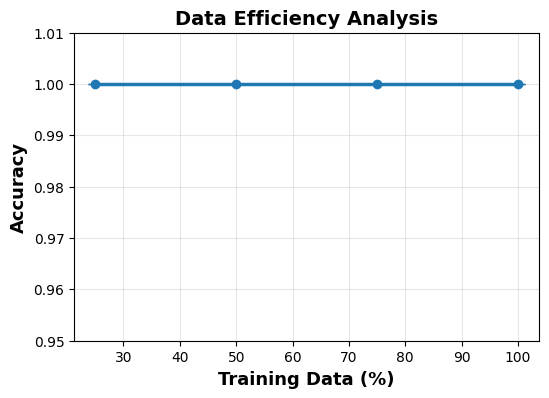

In [22]:
plt.figure(figsize=(6,4))

plt.errorbar(
    [r*100 for r in ratios],
    mean_acc,
    yerr=std_acc,
    marker='o',
    linewidth=2.5,
    capsize=5
)

plt.xlabel("Training Data (%)", fontsize=13, fontweight='bold')
plt.ylabel("Accuracy", fontsize=13, fontweight='bold')
plt.title("Data Efficiency Analysis", fontsize=14, fontweight='bold')

plt.grid(alpha=0.3)
plt.ylim(0.95, 1.01)

plt.savefig("data_efficiency_errorbars.png", dpi=2000)
plt.show()

In [23]:
# =========================================================
# STEP 11: CLASS IMBALANCE EXPERIMENT
# Uses learned features extracted in Step 10 corrected
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report

# --------------------------------------------------
# Check required variables
# --------------------------------------------------
print("Source learned feature shape:", source_features_norm.shape)
print("Target learned feature shape:", target_features_norm.shape)

# class mapping reminder:
# BF=0, GF=1, N=2, TF=3
imbalance_ratios = {
    2: 1.00,   # N  = 100%
    0: 0.50,   # BF = 50%
    1: 0.30,   # GF = 30%
    3: 0.20    # TF = 20%
}

class_names = ["BF", "GF", "N", "TF"]

# --------------------------------------------------
# Build imbalanced source set
# --------------------------------------------------
rng = np.random.RandomState(42)

X_imb_list = []
y_imb_list = []

for cls_id, keep_ratio in imbalance_ratios.items():
    idx = np.where(source_labels == cls_id)[0]
    n_keep = max(1, int(len(idx) * keep_ratio))

    chosen = rng.choice(idx, size=n_keep, replace=False)

    X_imb_list.append(source_features_norm[chosen])
    y_imb_list.append(source_labels[chosen])

X_imb = np.vstack(X_imb_list)
y_imb = np.hstack(y_imb_list)

# shuffle final imbalanced set
perm = rng.permutation(len(y_imb))
X_imb = X_imb[perm]
y_imb = y_imb[perm]

print("\nImbalanced source set counts:")
for i, name in enumerate(class_names):
    print(f"{name}: {(y_imb == i).sum()} samples")

# --------------------------------------------------
# Train classifier on imbalanced source features
# --------------------------------------------------
clf_imb = LogisticRegression(
    max_iter=5000,
    random_state=42
)
clf_imb.fit(X_imb, y_imb)

preds_imb = clf_imb.predict(target_features_norm)

acc_imb = accuracy_score(target_labels, preds_imb)
f1_imb = f1_score(target_labels, preds_imb, average="macro")
bacc_imb = balanced_accuracy_score(target_labels, preds_imb)

print("\nImbalance experiment results:")
print(f"Accuracy          : {acc_imb:.4f}")
print(f"Macro F1          : {f1_imb:.4f}")
print(f"Balanced Accuracy : {bacc_imb:.4f}")

print("\nClassification report:\n")
print(classification_report(target_labels, preds_imb, target_names=class_names, zero_division=0))

# --------------------------------------------------
# Save metrics text file
# --------------------------------------------------
imb_metrics_path = os.path.join(FIG_DIR, "class_imbalance_metrics.txt")
with open(imb_metrics_path, "w", encoding="utf-8") as f:
    f.write("Class imbalance experiment\n")
    f.write("Source imbalance ratios:\n")
    f.write("BF = 50%\n")
    f.write("GF = 30%\n")
    f.write("N  = 100%\n")
    f.write("TF = 20%\n\n")
    f.write(f"Accuracy\t{acc_imb:.6f}\n")
    f.write(f"MacroF1\t{f1_imb:.6f}\n")
    f.write(f"BalancedAccuracy\t{bacc_imb:.6f}\n")

print("Saved metrics table:", imb_metrics_path)

# --------------------------------------------------
# Save bar chart
# --------------------------------------------------
metric_names = ["Accuracy", "Macro F1", "Balanced Acc"]
metric_vals = [acc_imb, f1_imb, bacc_imb]

plt.figure(figsize=(6.2, 4.8))
bars = plt.bar(metric_names, metric_vals)

for i, v in enumerate(metric_vals):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.ylabel("Score", fontsize=13, fontweight="bold")
plt.title("Class Imbalance Robustness", fontsize=14, fontweight="bold")
plt.ylim(0, 1.08)
plt.grid(axis="y", alpha=0.3)

imb_fig_path = os.path.join(FIG_DIR, "class_imbalance_results.png")
plt.tight_layout()
plt.savefig(imb_fig_path, dpi=2000, bbox_inches="tight")
plt.close()

print("Saved figure:", imb_fig_path)
print("\nStep 11 completed successfully.")

Source learned feature shape: (448, 64)
Target learned feature shape: (90, 64)

Imbalanced source set counts:
BF: 56 samples
GF: 33 samples
N: 116 samples
TF: 21 samples

Imbalance experiment results:
Accuracy          : 1.0000
Macro F1          : 1.0000
Balanced Accuracy : 1.0000

Classification report:

              precision    recall  f1-score   support

          BF       1.00      1.00      1.00        22
          GF       1.00      1.00      1.00        22
           N       1.00      1.00      1.00        23
          TF       1.00      1.00      1.00        23

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Saved metrics table: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\class_imbalance_metrics.txt
Saved figure: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\class_imbalance_results.png

Step 11 completed successfully.


In [24]:
# =========================================================
# STEP 12: 5-FOLD CROSS VALIDATION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = source_features_norm
y = source_labels

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

fold_id = 1

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = LogisticRegression(max_iter=5000)

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")

    fold_results.append([acc, prec, rec, f1])

    print(f"Fold {fold_id} -> Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")

    fold_id += 1

fold_results = np.array(fold_results)

mean_results = fold_results.mean(axis=0)

print("\nMean Results")
print(f"Accuracy : {mean_results[0]:.4f}")
print(f"Precision: {mean_results[1]:.4f}")
print(f"Recall   : {mean_results[2]:.4f}")
print(f"F1 Score : {mean_results[3]:.4f}")

# =========================================================
# Save fold accuracy figure
# =========================================================

plt.figure(figsize=(6,4))

fold_acc = fold_results[:,0]

plt.bar(range(1,6), fold_acc)

for i, v in enumerate(fold_acc):
    plt.text(i+1, v+0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.xlabel("Fold", fontsize=13, fontweight='bold')
plt.ylabel("Accuracy", fontsize=13, fontweight='bold')
plt.title("5-Fold Cross Validation Accuracy", fontsize=14, fontweight='bold')

plt.ylim(0,1.05)

plt.grid(axis='y', alpha=0.3)

cv_fig_path = os.path.join(FIG_DIR,"kfold_accuracy.png")

plt.tight_layout()
plt.savefig(cv_fig_path, dpi=2000)

plt.close()

print("\nSaved figure:", cv_fig_path)

print("\nStep 12 completed successfully.")

Fold 1 -> Acc 1.0000 | Prec 1.0000 | Rec 1.0000 | F1 1.0000
Fold 2 -> Acc 1.0000 | Prec 1.0000 | Rec 1.0000 | F1 1.0000
Fold 3 -> Acc 1.0000 | Prec 1.0000 | Rec 1.0000 | F1 1.0000
Fold 4 -> Acc 1.0000 | Prec 1.0000 | Rec 1.0000 | F1 1.0000
Fold 5 -> Acc 1.0000 | Prec 1.0000 | Rec 1.0000 | F1 1.0000

Mean Results
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Saved figure: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\kfold_accuracy.png

Step 12 completed successfully.


In [25]:
# =========================================================
# STEP 13: NONLINEAR FEATURE ABLATION (FINAL CORRECT VERSION)
# =========================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

model.eval()

# ---------------------------------------------------------
# Extract SOURCE features for training
# ---------------------------------------------------------
src_early = []
src_global = []
src_patch = []
src_labels = []

with torch.no_grad():
    for x, y, d, Pg, Pp in src_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(
            x, Pg, d, grl_lam=0.0
        )

        # mean pool sequence features -> 2D
        z_early_mean = z_early.mean(dim=1)   # (B, D)
        z_patch_mean = z_patch.mean(dim=1)   # (B, D)

        src_early.append(z_early_mean.cpu().numpy())
        src_global.append(feats.cpu().numpy())
        src_patch.append(z_patch_mean.cpu().numpy())
        src_labels.append(y.cpu().numpy())

src_early = np.vstack(src_early)
src_global = np.vstack(src_global)
src_patch = np.vstack(src_patch)
src_labels = np.hstack(src_labels)

# ---------------------------------------------------------
# Extract TARGET TEST features for testing
# ---------------------------------------------------------
tgt_early = []
tgt_global = []
tgt_patch = []
tgt_labels = []

with torch.no_grad():
    for x, y, d, Pg, Pp in tgt_test_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(
            x, Pg, d, grl_lam=0.0
        )

        z_early_mean = z_early.mean(dim=1)   # (B, D)
        z_patch_mean = z_patch.mean(dim=1)   # (B, D)

        tgt_early.append(z_early_mean.cpu().numpy())
        tgt_global.append(feats.cpu().numpy())
        tgt_patch.append(z_patch_mean.cpu().numpy())
        tgt_labels.append(y.cpu().numpy())

tgt_early = np.vstack(tgt_early)
tgt_global = np.vstack(tgt_global)
tgt_patch = np.vstack(tgt_patch)
tgt_labels = np.hstack(tgt_labels)

print("Source early feature shape :", src_early.shape)
print("Source global feature shape:", src_global.shape)
print("Source patch feature shape :", src_patch.shape)

print("Target early feature shape :", tgt_early.shape)
print("Target global feature shape:", tgt_global.shape)
print("Target patch feature shape :", tgt_patch.shape)

results = {}

# ---------------------------------------------------------
# Model A: Early representation only
# ---------------------------------------------------------
clf_A = LogisticRegression(max_iter=5000, random_state=42)
clf_A.fit(src_early, src_labels)
preds_A = clf_A.predict(tgt_early)

acc_A = accuracy_score(tgt_labels, preds_A)
f1_A = f1_score(tgt_labels, preds_A, average="macro")
bacc_A = balanced_accuracy_score(tgt_labels, preds_A)

results["Early only"] = (acc_A, f1_A, bacc_A)

# ---------------------------------------------------------
# Model B: Early + Global nonlinear
# ---------------------------------------------------------
X_train_B = np.concatenate([src_early, src_global], axis=1)
X_test_B  = np.concatenate([tgt_early, tgt_global], axis=1)

clf_B = LogisticRegression(max_iter=5000, random_state=42)
clf_B.fit(X_train_B, src_labels)
preds_B = clf_B.predict(X_test_B)

acc_B = accuracy_score(tgt_labels, preds_B)
f1_B = f1_score(tgt_labels, preds_B, average="macro")
bacc_B = balanced_accuracy_score(tgt_labels, preds_B)

results["Early + Global"] = (acc_B, f1_B, bacc_B)

# ---------------------------------------------------------
# Model C: Early + Global + Patch nonlinear
# ---------------------------------------------------------
X_train_C = np.concatenate([src_early, src_global, src_patch], axis=1)
X_test_C  = np.concatenate([tgt_early, tgt_global, tgt_patch], axis=1)

clf_C = LogisticRegression(max_iter=5000, random_state=42)
clf_C.fit(X_train_C, src_labels)
preds_C = clf_C.predict(X_test_C)

acc_C = accuracy_score(tgt_labels, preds_C)
f1_C = f1_score(tgt_labels, preds_C, average="macro")
bacc_C = balanced_accuracy_score(tgt_labels, preds_C)

results["Early + Global + Patch"] = (acc_C, f1_C, bacc_C)

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------
print("\nNonlinear Feature Ablation Results\n")
for k, (acc, f1, bacc) in results.items():
    print(f"{k:25s} -> Accuracy {acc:.4f} | Macro F1 {f1:.4f} | Balanced Acc {bacc:.4f}")

# ---------------------------------------------------------
# Save metrics table
# ---------------------------------------------------------
ablation_txt = os.path.join(FIG_DIR, "nonlinear_ablation_metrics.txt")
with open(ablation_txt, "w", encoding="utf-8") as f:
    f.write("Model\tAccuracy\tMacroF1\tBalancedAccuracy\n")
    for k, (acc, f1, bacc) in results.items():
        f.write(f"{k}\t{acc:.6f}\t{f1:.6f}\t{bacc:.6f}\n")

print("\nSaved metrics table:", ablation_txt)

# ---------------------------------------------------------
# Plot accuracy bar chart
# ---------------------------------------------------------
labels_plot = list(results.keys())
acc_values = [results[k][0] for k in labels_plot]

plt.figure(figsize=(7, 4.8))
bars = plt.bar(labels_plot, acc_values)

for i, v in enumerate(acc_values):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel("Accuracy", fontsize=13, fontweight='bold')
plt.title("Nonlinear Feature Ablation", fontsize=14, fontweight='bold')
plt.ylim(0, 1.08)
plt.grid(axis='y', alpha=0.3)

ablation_path = os.path.join(FIG_DIR, "nonlinear_ablation.png")
plt.tight_layout()
plt.savefig(ablation_path, dpi=2000, bbox_inches="tight")
plt.close()

print("Saved figure:", ablation_path)
print("\nStep 13 completed successfully.")

Source early feature shape : (448, 64)
Source global feature shape: (448, 64)
Source patch feature shape : (448, 64)
Target early feature shape : (90, 64)
Target global feature shape: (90, 64)
Target patch feature shape : (90, 64)

Nonlinear Feature Ablation Results

Early only                -> Accuracy 0.9333 | Macro F1 0.9325 | Balanced Acc 0.9338
Early + Global            -> Accuracy 1.0000 | Macro F1 1.0000 | Balanced Acc 1.0000
Early + Global + Patch    -> Accuracy 1.0000 | Macro F1 1.0000 | Balanced Acc 1.0000

Saved metrics table: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\nonlinear_ablation_metrics.txt
Saved figure: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\nonlinear_ablation.png

Step 13 completed successfully.


In [26]:
# =========================================================
# STEP 14: SEPARATE FIGURES FOR EACH ABLATION MODEL
# Same quality/style as proposed method
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# Utility: save confusion matrix
# ---------------------------------------------------------
def save_confusion_matrix(cm, class_names, save_path, title):
    plt.figure(figsize=(5.8, 5.8))
    plt.imshow(cm, cmap="Blues")

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, fontsize=14, fontweight="bold")
    plt.yticks(ticks, class_names, fontsize=14, fontweight="bold")

    plt.gca().set_xticks(np.arange(-.5, len(class_names), 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, len(class_names), 1), minor=True)
    plt.grid(which="minor", color="black", linestyle="-", linewidth=1.5)
    plt.tick_params(which="minor", bottom=False, left=False)

    thresh = cm.max() * 0.55 if cm.max() > 0 else 0.5
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.xlabel("Predicted Class", fontsize=15, fontweight="bold")
    plt.ylabel("True Class", fontsize=15, fontweight="bold")
    plt.title(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=2000, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# Utility: save ROC
# ---------------------------------------------------------
def save_roc_curves(y_true, y_prob, class_names, save_path, title):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    line_styles = ["-", "--", "-.", ":"]
    line_widths = [2.5, 2.5, 2.8, 2.8]

    plt.figure(figsize=(6.6, 5.6))

    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr, tpr,
            linestyle=line_styles[c % len(line_styles)],
            linewidth=line_widths[c % len(line_widths)],
            label=f"{class_names[c]} (AUC={roc_auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1.8, label="Chance")
    plt.xlabel("False Positive Rate", fontsize=13, fontweight="bold")
    plt.ylabel("True Positive Rate", fontsize=13, fontweight="bold")
    plt.title(title, fontsize=14, fontweight="bold")

    leg = plt.legend(fontsize=11, frameon=True)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.5)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=2000, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# Utility: save t-SNE
# ---------------------------------------------------------
def save_tsne(features, labels, class_names, save_path, title):
    tsne = TSNE(
        n_components=2,
        perplexity=25,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    Z = tsne.fit_transform(features)

    markers = ["o", "s", "^", "D"]

    plt.figure(figsize=(6.8, 6.8))
    for c, name in enumerate(class_names):
        idx = labels == c
        plt.scatter(
            Z[idx, 0], Z[idx, 1],
            s=95,
            marker=markers[c % len(markers)],
            edgecolors="black",
            linewidths=1.2,
            alpha=0.9,
            label=name
        )

    plt.xlabel("t-SNE 1", fontsize=13, fontweight="bold")
    plt.ylabel("t-SNE 2", fontsize=13, fontweight="bold")
    plt.title(title, fontsize=14, fontweight="bold")

    leg = plt.legend(fontsize=12, frameon=True)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(2.0)
    leg.get_frame().set_alpha(1.0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=2000, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# Build 2D features again if not already in memory
# ---------------------------------------------------------
model.eval()

src_early = []
src_global = []
src_patch = []
src_labels = []

tgt_early = []
tgt_global = []
tgt_patch = []
tgt_labels = []

with torch.no_grad():
    for x, y, d, Pg, Pp in src_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(x, Pg, d, grl_lam=0.0)

        src_early.append(z_early.mean(dim=1).cpu().numpy())
        src_global.append(feats.cpu().numpy())
        src_patch.append(z_patch.mean(dim=1).cpu().numpy())
        src_labels.append(y.cpu().numpy())

    for x, y, d, Pg, Pp in tgt_test_loader:
        x = x.to(device)
        y = y.to(device)
        d = d.to(device)
        Pg = Pg.to(device)

        fault_logits, domain_logits, feats, z_patch, z_early = model(x, Pg, d, grl_lam=0.0)

        tgt_early.append(z_early.mean(dim=1).cpu().numpy())
        tgt_global.append(feats.cpu().numpy())
        tgt_patch.append(z_patch.mean(dim=1).cpu().numpy())
        tgt_labels.append(y.cpu().numpy())

src_early = np.vstack(src_early)
src_global = np.vstack(src_global)
src_patch = np.vstack(src_patch)
src_labels = np.hstack(src_labels)

tgt_early = np.vstack(tgt_early)
tgt_global = np.vstack(tgt_global)
tgt_patch = np.vstack(tgt_patch)
tgt_labels = np.hstack(tgt_labels)

class_names = ["BF", "GF", "N", "TF"]

# ---------------------------------------------------------
# Prepare model variants
# ---------------------------------------------------------
variants = {
    "early_only": {
        "X_train": src_early,
        "X_test": tgt_early,
        "title": "Early Only"
    },
    "early_global": {
        "X_train": np.concatenate([src_early, src_global], axis=1),
        "X_test": np.concatenate([tgt_early, tgt_global], axis=1),
        "title": "Early + Global"
    },
    "early_global_patch": {
        "X_train": np.concatenate([src_early, src_global, src_patch], axis=1),
        "X_test": np.concatenate([tgt_early, tgt_global, tgt_patch], axis=1),
        "title": "Early + Global + Patch"
    }
}

# ---------------------------------------------------------
# Train + evaluate each variant
# ---------------------------------------------------------
for key, item in variants.items():
    X_train = item["X_train"]
    X_test = item["X_test"]
    title = item["title"]

    clf = LogisticRegression(max_iter=5000, random_state=42)
    clf.fit(X_train, src_labels)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)

    cm = confusion_matrix(tgt_labels, y_pred)
    report = classification_report(tgt_labels, y_pred, target_names=class_names, digits=4)

    cm_path = os.path.join(FIG_DIR, f"cm_{key}.png")
    roc_path = os.path.join(FIG_DIR, f"roc_{key}.png")
    tsne_path = os.path.join(FIG_DIR, f"tsne_{key}.png")
    report_path = os.path.join(FIG_DIR, f"classification_report_{key}.txt")

    save_confusion_matrix(cm, class_names, cm_path, f"{title} Confusion Matrix")
    save_roc_curves(tgt_labels, y_prob, class_names, roc_path, f"{title} ROC Curves")
    save_tsne(X_test, tgt_labels, class_names, tsne_path, f"{title} t-SNE")

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report)

    print(f"\n{title}")
    print(report)
    print("Saved:", cm_path)
    print("Saved:", roc_path)
    print("Saved:", tsne_path)
    print("Saved:", report_path)

print("\nStep 14 completed successfully.")


Early Only
              precision    recall  f1-score   support

          BF     0.8800    1.0000    0.9362        22
          GF     0.8696    0.9091    0.8889        22
           N     1.0000    0.8261    0.9048        23
          TF     1.0000    1.0000    1.0000        23

    accuracy                         0.9333        90
   macro avg     0.9374    0.9338    0.9325        90
weighted avg     0.9388    0.9333    0.9329        90

Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\cm_early_only.png
Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\roc_early_only.png
Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\tsne_early_only.png
Saved: F:\MCTPAPER_NEW_SSM MAMBA\Study2\1320_1440\FULL_MODEL_NEW\figures\classification_report_early_only.txt

Early + Global
              precision    recall  f1-score   support

          BF     1.0000    1.0000    1.0000        22
          GF     1.0000    1.0000    1.000